<font size="5"><center>Taller de procesamiento de señales

<font size="5">Trabajo práctico N°10

<font size="5">Alumno: Santiago Cabrera

<font size="5">Padrón: 110.445

In [77]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.special as sp

#a) Creación del dataset

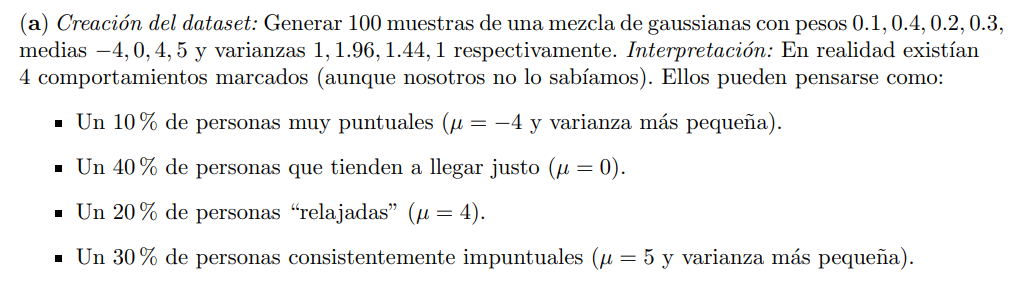

In [78]:
N = 100

medias = np.array([-4, 0, 4, 5])
medias = medias.reshape(-1, 1)
varianzas = np.array([1, 1.96, 1.44, 1])
varianzas = varianzas.reshape((4, 1, 1))
pesos = np.array([0.1, 0.4, 0.2, 0.3]) # NG1=10, NG2=40, NG3=20, NG4=30

X = np.empty(0)
y = np.empty(0)

for i in range(len(medias)):
    n_muestras = int(N * pesos[i])
    componente_X = np.random.normal(medias[i], np.sqrt(varianzas[i][0][0]), n_muestras)
    etiquetas = np.full(n_muestras, i) #vector de tamaño (n_muestras, ), todos los valores son i

    X = np.append(X, componente_X)
    y = np.append(y, etiquetas)

indices = np.arange(N)
np.random.shuffle(indices)
X = X[indices]
X = X.reshape(-1, 1) #lo paso a matriz
y = y[indices]

#b) K-means

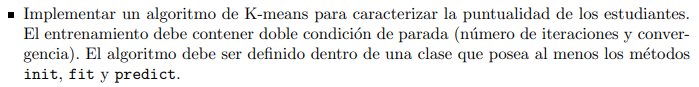

In [79]:
class Kmeans:
  def __init__(self, K, n_iter, tol):
    self.K = K
    self.n_iter = n_iter
    self.tol = tol

    self.means_anteriores = None
    self.means = None #centroides
    self.etiquetas = None

    self.covarianzas = None
    self.pesos = None

  def fit(self, X):
    #X tiene dimensión (n,m). Cada dato es una fila, hay n datos, cada uno de los cuales tiene m columnas
    indices_random = np.random.choice(X.shape[0], size = self.K, replace = False)
    #obs: K debe ser menor a n
    self.means = X[indices_random, :] #matriz de (k, m)

    self.etiquetas = np.zeros(shape = (X.shape[0], ))

    n = X.shape[0]#número de datos
    m = X.shape[1]#número de características

    iter = 0
    while(iter < self.n_iter):

      X_reshape = X.reshape(n, 1, m)
      centroides_reshape = self.means.reshape(1, self.K, m)
      #hago este cambio de dimensión para poder calcular las distancias sin un for
      distancias = np.linalg.norm(X_reshape - centroides_reshape, axis = 2) #(n, K)
      self.etiquetas = np.argmin(distancias, axis = 1) #(n,)

      #recalculo los centroides
      self.means_anteriores = self.means
      for k in range(self.K):
        cluster_data = X[self.etiquetas == k] #datos en el cluster k
        #DUDA: qué pasa si un cluster queda vacío? Es decir ¿qué pasa si self.etiquetas == k no devuelve nada?
        if(cluster_data.shape[0] > 0):
          self.means[k, :] = np.mean(cluster_data, axis = 0)
        else:
          self.means[k, :] = self.means[k, :]
          #Si un cluster queda vacío, el centroide no se mueve.

      iter += 1

      delta_centroides = np.linalg.norm(self.means - self.means_anteriores, axis = 1) #(k, m)
      if np.any(delta_centroides > self.tol):
        continue
      else:
        break

    self.covarianzas = np.zeros((self.K, m, m))
    self.pesos = np.zeros(self.K)
    for k in range(self.K):
      cluster_data = X[self.etiquetas == k]
      N_datos = cluster_data.shape[0]
      matriz = np.cov(cluster_data, rowvar = False)
      if matriz.shape == ():
        matriz = matriz.reshape((1, 1)) #quiero que sea una matriz de 1x1
      self.covarianzas[k] = matriz
      self.pesos[k] = N_datos / n

    return None

  def predict(self, X):
    n = X.shape[0]
    m = X.shape[1]

    X_reshape = X.reshape(n, 1, m)
    centroides_reshape = self.means.reshape(1, self.K, m)
    distancias = np.linalg.norm(X_reshape - centroides_reshape, axis = 2)

    etiquetas = np.argmin(distancias, axis = 1)
    return etiquetas

  def get_params(self):
    return self.means, self.covarianzas, self.pesos

In [80]:
mi_kmeans = Kmeans(K = 6, n_iter = 10000, tol = 0.01)
mi_kmeans.fit(X)
medias_kmeans, covarianzas_kmeans, pesos_kmeans = mi_kmeans.get_params()

$ X_k $ ---> k-ésima gaussiana

$ Y $ ---> mezcladora


$p(x) = \sum_k p(x_k | y = k) \cdot p(y = k)$


In [81]:
def gaussiana_multivariada(x, mean, cov): #evalua la pdf de una gaussiana multivariada dadas las medias y la covarianza

    k = len(mean)
    det_cov = np.linalg.det(cov)
    inv_cov = np.linalg.inv(cov)

    diff = x - mean
    exponent = -0.5 * np.sum(diff @ inv_cov * diff, axis=1)

    normalization = (2 * np.pi)**(-k/2) * det_cov**(-0.5)

    return normalization * np.exp(exponent)

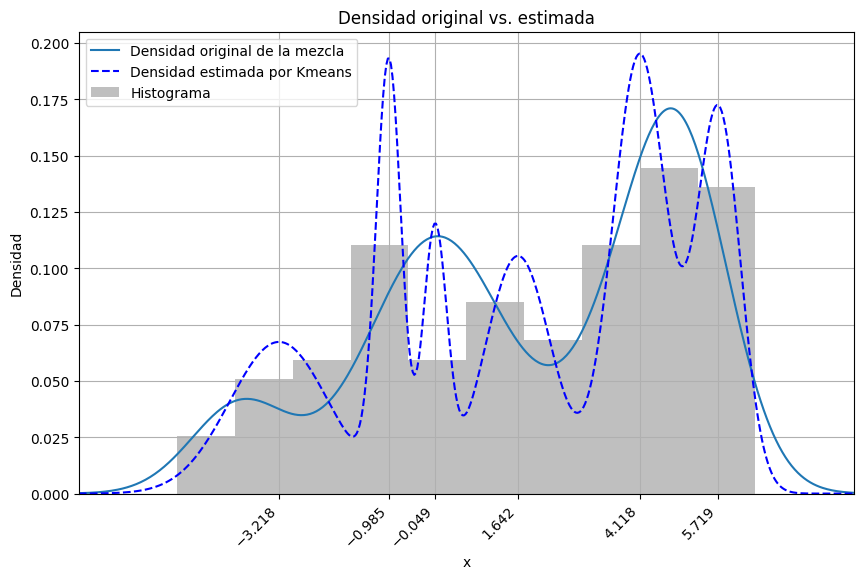

In [82]:
e = 2
x_rango = np.linspace(X.min() - e, X.max() + e, 500)

densidad_estimada_kmeans = np.zeros_like(x_rango)
densidad_original = np.zeros_like(x_rango)

for k in range(len(medias_kmeans)):
    media_k = medias_kmeans[k]
    varianza_k = covarianzas_kmeans[k]
    peso_k = pesos_kmeans[k]
    pdf = gaussiana_multivariada(x_rango.reshape(-1, 1), media_k, varianza_k)
    densidad_estimada_kmeans += peso_k * pdf

for k in range(len(medias)):
    media_k = medias[k]
    varianza_k = varianzas[k]
    peso_k = pesos[k]
    pdf = gaussiana_multivariada(x_rango.reshape(-1, 1), media_k, varianza_k)
    densidad_original += peso_k * pdf

plt.figure(figsize=(10, 6))

plt.plot(x_rango, densidad_original, label = 'Densidad original de la mezcla')
plt.plot(x_rango, densidad_estimada_kmeans, label = 'Densidad estimada por Kmeans', color = 'blue', linestyle = '--')
plt.hist(X, density = True, label = 'Histograma', color = 'gray', alpha = 0.5)

x_ticks = [m[0] for m in medias_kmeans]
plt.xticks(x_ticks, rotation = 45, ha = 'right')

plt.title('Densidad original vs. estimada')
plt.xlabel('x')
plt.xlim(X.min() - e, X.max() + e)
plt.ylabel('Densidad')
plt.legend()
plt.grid(True)
plt.show()

En el gráfico se resaltan las 6 medias aprendidadas por Kmeans. El ancho de cada una de las 6 campanas está relacionado con la varianza de cada una de las 6 clases.

Corriendo el código distintas veces se observan resultados distintos. Esto se debe a que kmeans inicializa los centroides de forma aleatoria.

Se observa que la densidad estimada tiene tantos picos como clases ($K = 6$). Sin embargo, en la densidad original solo se observan 3 picos ya que las campanas de las clases "personas relajadas" ($\mu = 4$, $\sigma = 1.44$, $p = 0.2$) y "personas consistentemente impuntuales ($\mu = 5$, $\sigma = 1$, $p = 0.3$) se solapan. Esto podría indicar que el desempeño del algoritmo mejoraría si se elige $K = 3$

Se observa también que la densidad estimada por Kmeans se ajusta bien a los datos observados, pero no tan bien a la densidad original. Esto sugiere que se necesitan más datos


#c) Expectación-maximización

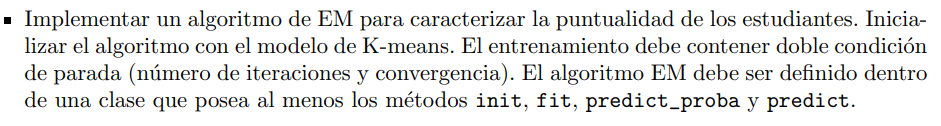

In [97]:
class EM:
  def __init__(self, K, n_iter, tol, n_iter_kmeans = 1000, tol_kmeans = 0.001):
    self.n_iter = n_iter
    self.tol = tol
    self.K = K
    self.medias = None
    self.covarianzas = None
    self.pesos = None
    self.pesos_anteriores = None
    self.kmeans = Kmeans(self.K, n_iter = n_iter_kmeans, tol = tol_kmeans)
    self.q = None

  def fit(self, X):
    #Paso 0. Inicializo los parámetros de mis K distribuciones gaussianas con Kmeans

    self.kmeans.fit(X)
    self.medias, self.covarianzas, self.pesos = self.kmeans.get_params()
    n, m = X.shape #n = cantidad de datos. m = características por dato

    #fin paso 0
    probas_anteriores = self.predict_proba(X) #va a ser mi condición de corte
    n_iter = 0
    while n_iter < self.n_iter:
      n_iter += 1

      #Paso E. Para cada dato calculo la probabilidad de pertenencia a cada gaussiana

      p_x_k = np.zeros((n, self.K))

      for k in range(self.K):
        p_x_k[:, k] = self.pesos[k] * gaussiana_multivariada(X, self.medias[k], self.covarianzas[k])

      q = p_x_k / np.sum(p_x_k, axis = 1, keepdims = True)
      #Fin paso E

      #Paso M: Para cada gaussiana calculo los parámetros que maximicen las probabilidades antes calculadas

      #recalculo pesos
      self.pesos = np.mean(q, axis = 0)

      #recalculo medias
      den = np.sum(q, axis = 0)
      self.medias = q.T @ X / den.reshape(len(den), 1) #división elemento a elemento. Necesito reshape


      #recalculo covarianzas
      for k in range(self.K):
        diff = X - self.medias[k] #(200, m)
        pesos = q[:, k].reshape(n, 1) #(200, 1)
        #numerador: suma_i q(k|x_i) * (diff)(diff))^T
        self.covarianzas[k] = (diff.T @ (pesos * diff)) / np.sum(pesos)

      self.q = q

      #fin paso M

      #condición de convergencia
      probas_actuales = self.predict_proba(X)
      delta_probas = np.abs(probas_actuales - probas_anteriores)
      if np.any(delta_probas > self.tol):
        probas_anteriores = probas_actuales
        continue
      else:
        print(f'Se hicieron {n_iter} iteraciones')
        return

    print(f'Se hicieron {n_iter} iteraciones')

  def predict_proba(self, X):
    n, m = X.shape
    probas = np.zeros((n, self.K)) #en cada dato calculo la proba de pertenecer al cluster k

    for k in range(self.K):
      probas[:, k] = gaussiana_multivariada(X, self.medias[k], self.covarianzas[k]) * self.pesos[k]

    return probas / np.sum(probas, axis = 1, keepdims = True)

  def predict(self, X):
    probas = self.predict_proba(X)
    return np.argmax(probas, axis = 1)

  def get_params(self):
    return self.medias, self.covarianzas, self.pesos

Nota: el criterio de convergencia fue que las probabilidades para los datos de entrenamiento dejaran de cambiar

In [98]:
mi_EM = EM(K = 6, n_iter = 10000, tol = 1e-6)
mi_EM.fit(X)

medias_EM, covarianzas_EM, pesos_EM = mi_EM.get_params()

Se hicieron 676 iteraciones


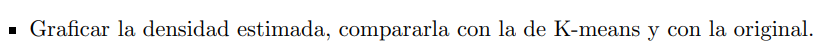

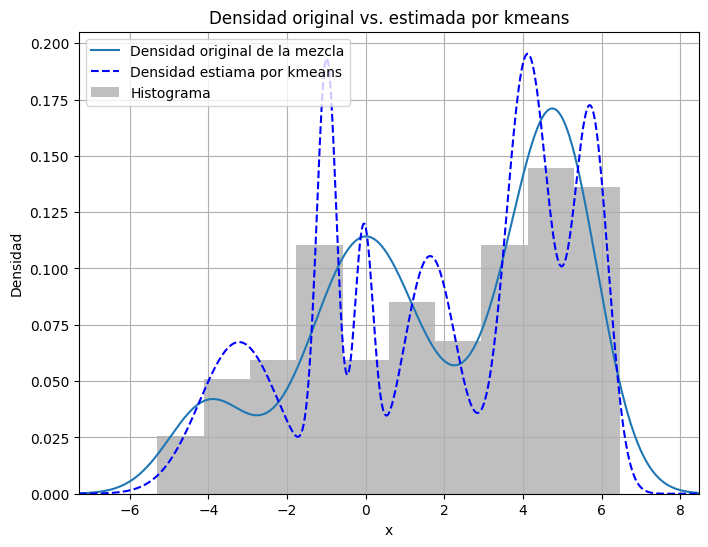

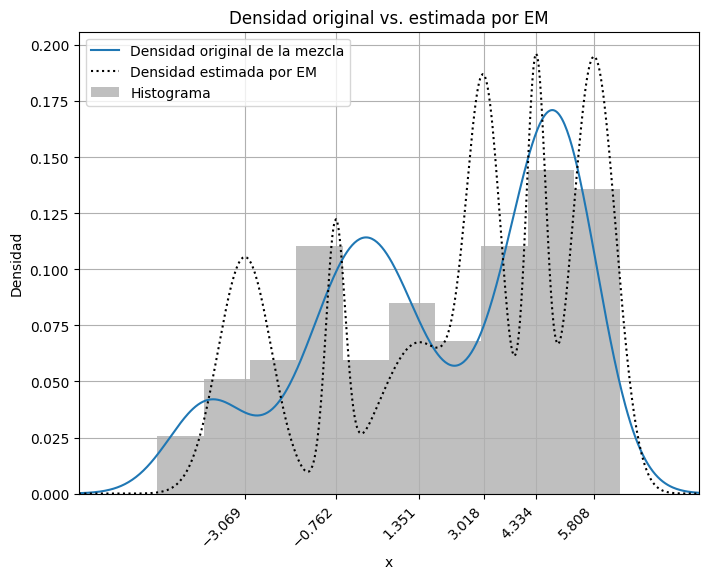

In [99]:
e = 2
x_rango = np.linspace(X.min() - e, X.max() + e, 500)

densidad_estimada_EM = np.zeros_like(x_rango)
densidad_original = np.zeros_like(x_rango)

for k in range(len(medias_EM)):
    media_k = medias_EM[k]
    varianza_k = covarianzas_kmeans[k]
    peso_k = pesos_kmeans[k]
    pdf = gaussiana_multivariada(x_rango.reshape(-1, 1), media_k, varianza_k)
    densidad_estimada_EM += peso_k * pdf

for k in range(len(medias)):
    media_k = medias[k]
    varianza_k = varianzas[k]
    peso_k = pesos[k]
    pdf = gaussiana_multivariada(x_rango.reshape(-1, 1), media_k, varianza_k)
    densidad_original += peso_k * pdf

plt.figure(figsize=(8, 6))

plt.plot(x_rango, densidad_original, label = 'Densidad original de la mezcla')
plt.plot(x_rango, densidad_estimada_kmeans, label = 'Densidad estiama por kmeans', linestyle = '--', color = 'b')
plt.hist(X, density = True, label = 'Histograma', color = 'gray', alpha = 0.5)
plt.title('Densidad original vs. estimada por kmeans')
plt.xlabel('x')
plt.xlim(X.min() - e, X.max() + e)
plt.ylabel('Densidad')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 6))


plt.plot(x_rango, densidad_original, label = 'Densidad original de la mezcla')
plt.plot(x_rango, densidad_estimada_EM, label = 'Densidad estimada por EM', linestyle = ':', color = 'k')
plt.hist(X, density = True, label = 'Histograma', color = 'gray', alpha = 0.5)

x_ticks = [m[0] for m in medias_EM]
plt.xticks(x_ticks, rotation = 45, ha = 'right')

plt.title('Densidad original vs. estimada por EM')
plt.xlabel('x')
plt.xlim(X.min() - e, X.max() + e)
plt.ylabel('Densidad')
plt.legend()
plt.grid(True)
plt.show()

Se observa que la densidad aprendida por EM es peor que la aprendida por kmeans

#d) Gaussian variational Bayes

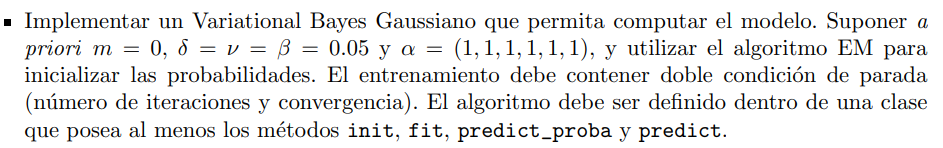

In [149]:
from scipy.special import gamma, digamma, softmax

class GVB:
  def __init__(self, K, Gamma, max_iter = 1000, tol = 1e-6, m0 = 0, delta0 = 0.05, beta0 = 0.05, nu0 = 0.05, alpha0 = None):
    self.K = K
    self.max_iter = max_iter
    self.tol = tol

    self.Gamma = Gamma
    #priors
    self.m0 = m0
    self.delta0 = delta0
    self.beta0 = beta0
    self.nu0 = nu0
    self.alpha0 = np.ones(K, dtype = float) if alpha0 is None else np.array(alpha0)

    #a posteriori
    self.alpha = None
    self.m = None
    self.delta = None
    self.nu = None
    self.beta = None
    #condición de corte
    self.Gamma_anterior = None

    self.m_list = []

  def actualizar_variacionales(self, X):
    Nk = self.Gamma.sum(axis = 0) #(K, )
    fk = (self.Gamma * X.reshape(-1, 1)).sum(axis = 0) #(K, )
    sk = (self.Gamma * (X.reshape(-1, 1)**2)).sum(axis = 0) #(K, )

    self.alpha = self.alpha0 + Nk #(K, )
    self.delta = self.delta0 + Nk #(K, )

    self.m_list.append(self.m)
    self.m = (self.delta0 * self.m0 + fk) / (self.delta0 + Nk) #(K, )
    self.nu = self.nu0 + 0.5 * Nk #(K, )
    self.beta = self.beta0 + 0.5 * self.delta0 * self.m0**2 + 0.5 * sk - 0.5 * (self.delta0 * self.m0 + fk)**2 / (self.delta0 + Nk) #(K, )


  def actualizar_gammas(self, X):
    X_col = X.reshape(-1, 1) #(n, 1)
    E_log_pi = (digamma(self.alpha) - digamma(np.sum(self.alpha))).reshape(1, -1) # (1, K)
    E_log_lambda = digamma(self.nu) - np.log(self.beta).reshape(1, -1) # (1, K)
    E_q2 = 1/self.delta + self.nu / self.beta * (X_col - self.m[None, :])**2 #(n, K)

    exponente = E_log_pi + 0.5 * E_log_lambda - 0.5 * E_q2

    return softmax(exponente, axis = 1)

  def fit(self, X):

    for n_iter in range(self.max_iter):
      self.actualizar_variacionales(X)
      self.Gamma_anterior = self.Gamma.copy()
      self.Gamma = self.actualizar_gammas(X)

      #condición de parada: los gamma dejan de cambiar
      delta_gamma = np.abs(self.Gamma - self.Gamma_anterior)
      if np.any(delta_gamma > self.tol):
        continue
      else:
        print(f'Se hicieron {n_iter} iteraciones')
        return

    print(f'Se hicieron {n_iter} iteraciones')


  def generar_params(self, n):
    pesos = np.random.dirichlet(alpha = self.alpha, size = n) #(3, 6)
    lambdas = np.random.gamma(shape = self.nu, scale = 1/self.beta, size = (n, self.K)) #(3, 6)
    medias = np.zeros((n, self.K))
    for i in range(self.K):
      media = self.m[i] * np.ones(n) #(3, )
      desviacion = np.sqrt(1/(lambdas[:, i] * (self.delta[i]))) #(3, )
      medias[:, i] = np.random.normal(loc = media, scale = desviacion, size = n)
    return pesos, lambdas, medias


  def predict_proba(self, X):
    return self.actualizar_gammas(X)

  def predict(self, X):
    return np.argmax(self.predict_proba(X), axis = 1)


In [150]:
Gamma = mi_EM.predict_proba(X)

K = 6

mi_GVB = GVB(K = K, Gamma = Gamma, max_iter = 5000, tol = 1e-3)
mi_GVB.fit(X)
alpha = mi_GVB.alpha

Se hicieron 214 iteraciones


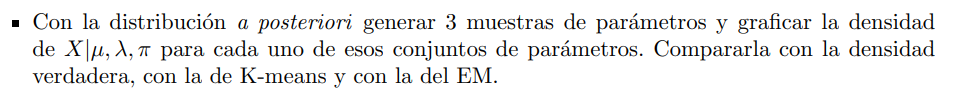

In [151]:
n = 3
pesos, lambdas, medias = mi_GVB.generar_params(n)

In [152]:
gvb_den = np.empty((3, len(x_rango)))

for i in range(n):
    densidad_actual = np.zeros_like(x_rango)
    for k in range(K):
        media_k = medias[i, k]
        media_k = np.array([media_k])
        lambda_k = lambdas[i, k]
        varianza_k = np.array([[1 / lambda_k]])
        peso_k = pesos[i, k]

        pdf = gaussiana_multivariada(x_rango.reshape(-1, 1), media_k, varianza_k)
        densidad_actual += peso_k * pdf
    gvb_den[i] = densidad_actual


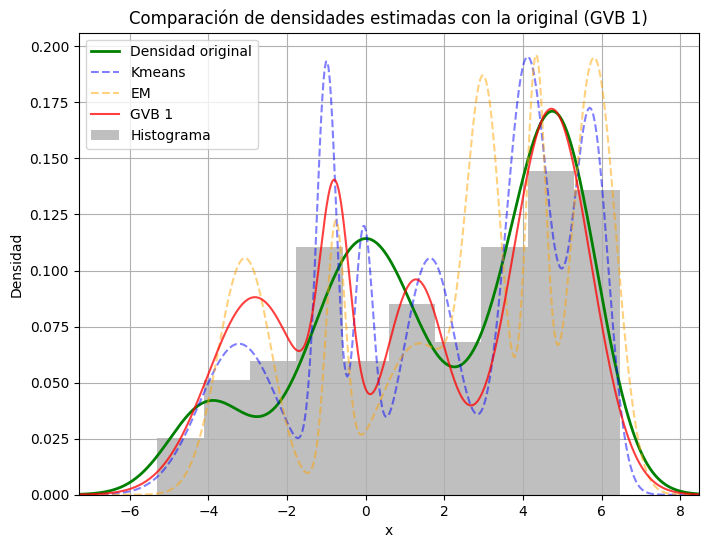

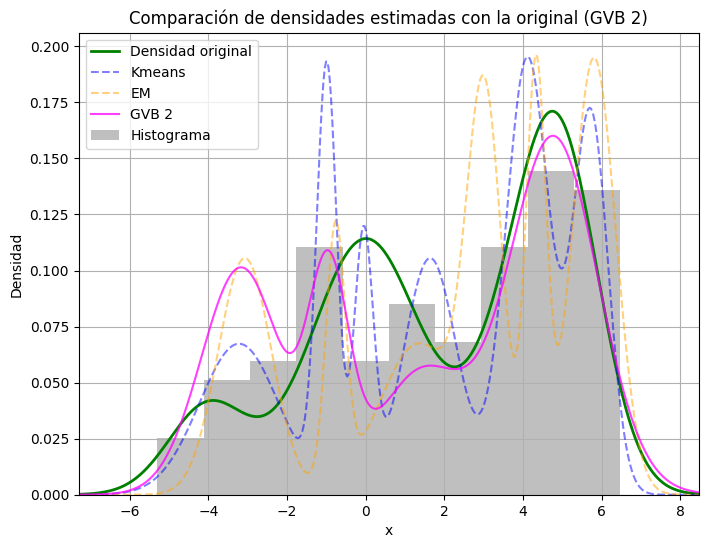

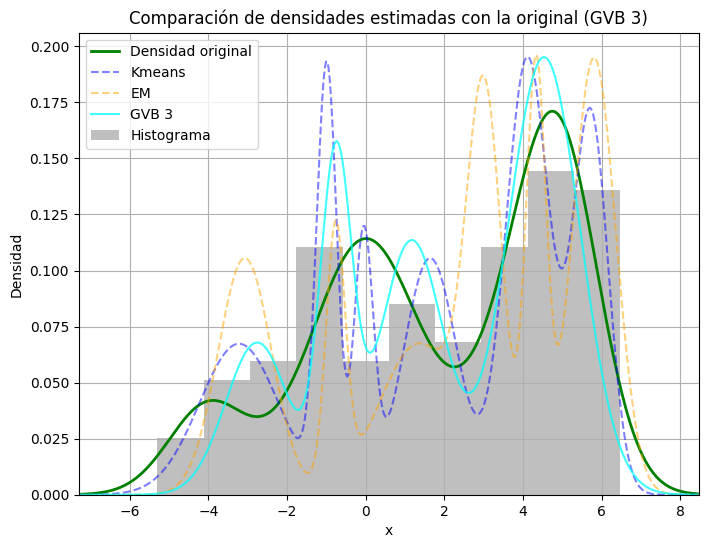

In [153]:
colores = ['red', 'magenta', 'cyan']
for i in range(n):
    plt.figure(figsize=(8, 6))

    plt.plot(x_rango, densidad_original, label = 'Densidad original', color = 'green', linewidth = 2)
    plt.plot(x_rango, densidad_estimada_kmeans, label = 'Kmeans', color = 'blue', linestyle = '--', alpha = 0.5)
    plt.plot(x_rango, densidad_estimada_EM, label = 'EM', color = 'orange', linestyle = '--', alpha = 0.5)

    plt.plot(x_rango, gvb_den[i], label = f'GVB {i+1}', alpha = 0.75, color = colores[i])

    plt.hist(X, density = True, label = 'Histograma', color = 'gray', alpha = 0.5)

    plt.title(f'Comparación de densidades estimadas con la original (GVB {i+1})')
    plt.xlabel('x')
    plt.xlim(X.min() - e, X.max() + e)
    plt.ylabel('Densidad')
    plt.legend()
    plt.grid(True)
    plt.show()

Se observa que las 3 densidades predichas por GVB son un poco distintas, reflejando la aleatoriedad con que se generan los parámetros de las distribuciones.

También se observa que el desempeño del algoritmo es mejor en donde más datos hay.

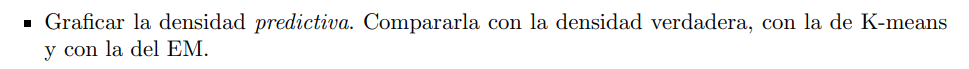

In [154]:
from scipy.stats import t
def predictiva_gvb(x, gvb):

    alpha = gvb.alpha
    m = gvb.m
    delta = gvb.delta
    nu = gvb.nu
    beta = gvb.beta

    E_pi = alpha / alpha.sum()
    df = 2 * nu
    #scale = 1/sqrt(lamda)
    Lambda = delta * nu /((delta + 1) * beta)
    scale = 1/np.sqrt(Lambda)

    dens = np.zeros_like(x, dtype = float)

    for k in range(gvb.K):
        dens += E_pi[k] * t.pdf(x, df = df[k], loc = m[k], scale = scale[k])

    return dens

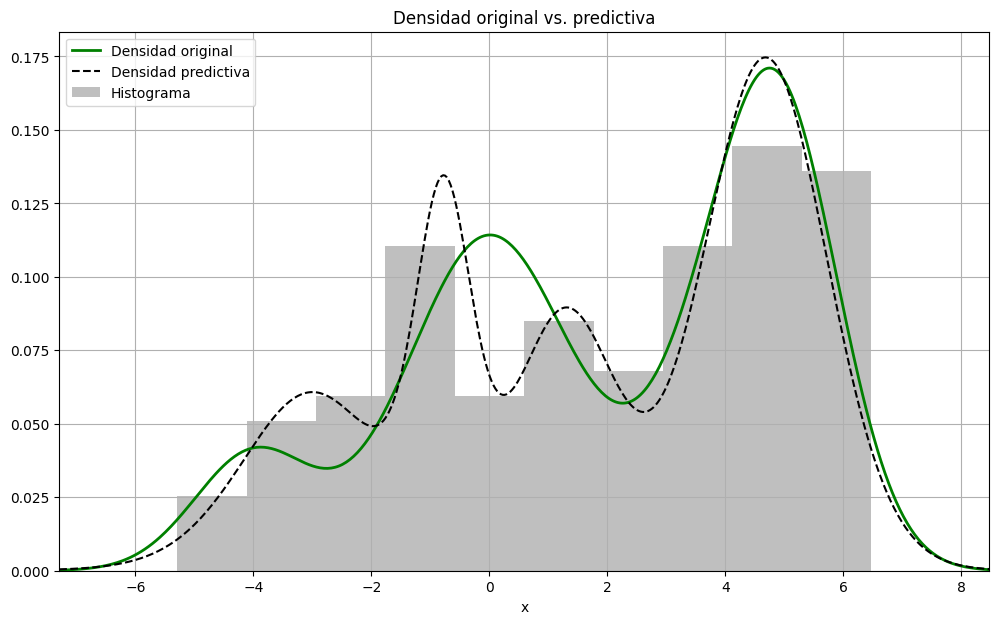

In [155]:
predictiva = predictiva_gvb(x_rango, mi_GVB)

plt.figure(figsize=(12, 7))

plt.plot(x_rango, densidad_original, label = 'Densidad original', color = 'green', linewidth = 2)
plt.plot(x_rango, predictiva, label = 'Densidad predictiva', color = 'k', linestyle='--', alpha = 1)
plt.hist(X, density = True, label = 'Histograma', color = 'gray', alpha = 0.5)

plt.title('Densidad original vs. predictiva')
plt.xlabel('x')
plt.xlim(X.min() - e, X.max() + e)
plt.legend()
plt.grid(True)
plt.show()

La predictiva es la mejor estimación de la densidad verdadera.